# DSA azimuth-scan (MeerKLASS-style): TOD simulation + map-making

This notebook mirrors the end-to-end pipeline for the DSA azimuth-scan strategy:

- Constant-elevation back-and-forth scans at **el = 55°** (~10° declination strip centred on Dec ≈ 53°).
- Two crossing scans (*setting* + *rising*) at mirrored azimuths give two distinct parallactic angles per pixel.
- Forward model via `limTOD.TODSim.generate_TOD`, inverse via `limTOD.HPW_mapmaking` (high-pass + Wiener filter).

**Scope.** This notebook exists as a quick-look, single-file view of the pipeline. Production figures in
`README.md` come from the MPI drivers under `scripts/` (`run_analysis_A.sh`,
`produce_focus_maps.py`, `produce_proposal_figures.py`). When the script caches exist on disk, this
notebook simply loads them and runs only the map-making — otherwise it regenerates each step.

Map-making recipe matches `scripts/compare_maps.run_mapmaking`: HP cutoff 30 mHz, order-4 Butterworth,
beam-smoothed truth as prior mean with `σ = std(sky_truth)`, and explicit per-sample noise variance
`white_var × (op_i @ sky_truth)²` so the Wiener filter does not fall back to its biased auto-estimate.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), '..', '..')))

import pickle
import numpy as np
import matplotlib.pyplot as plt
import healpy as hp

from limTOD import TODSim, example_scan, GDSM_sky_model, HPW_mapmaking
from dsa_vis import DSA_LAT, DSA_LON, DSA_HGT, dsa_beam_func, plot_map_compare

In [2]:
# TOD-simulation resolution — matches scripts/sim_meerklass_tod.py.
# (beam_nside=64 is the smallest resolution that keeps beam-rotation
# accuracy while avoiding the heavy nside=128 simulation cost.)
sky_Nside = 64
beam_Nside = 64

# Map-making resolution. Default ns=64 matches scripts/run_analysis_A.sh
# so we reuse the existing `mapmaker_ops_meerklass_ns64_baseline.pkl`
# operator cache. Set to 16 for a lighter (~3.7°/pixel) run that uses
# `mapmaker_ops_meerklass_ns16_baseline.pkl` instead.
sky_Nside_map = 64

tod_sim = TODSim(
    ant_latitude_deg=DSA_LAT,
    ant_longitude_deg=DSA_LON,
    ant_height_m=DSA_HGT,
    beam_func=dsa_beam_func,
    sky_func=GDSM_sky_model,
    beam_nside=beam_Nside,
    sky_nside=sky_Nside,
)

# Beam-edge truncation fraction. Same value is re-used as the mapmaker's
# beam_truncate_frac_thres so forward and inverse agree on the beam support.
truncate_frac_thres = 1e-3
freq_list = [1000]  # MHz

In [3]:
# Cache name matches scripts/sim_meerklass_tod.py --out-suffix _baseline,
# so if run_analysis_A.sh has already run the notebook just loads the
# cache and skips its own slow (~15 min) sim.
TOD_CACHE = "simulated_TODs_meerklass_baseline.npz"

try:
    data = np.load(TOD_CACHE, allow_pickle=True)
    freq_list = data["freq_list"].tolist()
    # Coerce to float64; the .npz stores TOD arrays as dtype=object (Python
    # floats boxed in numpy), which later breaks scipy.linalg.solve.
    TOD_group = [np.asarray(t, dtype=np.float64) for t in data["TOD_group"]]
    LST_deg_list_group = [np.asarray(x, dtype=np.float64)
                          for x in data["LST_deg_list_group"]]
    azimuth_deg_list_group = [np.asarray(x, dtype=np.float64)
                              for x in data["azimuth_deg_list_group"]]
    elevation_deg_list_group = [np.asarray(x, dtype=np.float64)
                                for x in data["elevation_deg_list_group"]]
    print(f"Loaded {len(TOD_group)} cached TODs from {TOD_CACHE}")
except (FileNotFoundError, KeyError):
    # Matches scripts/sim_meerklass_tod.py: el = 55°, ±60°…±42° az sweep,
    # n_repeats = 13. Start times tuned so RA-mean = 180° on both scans.
    el_scan = 55.0
    SCANS = [
        dict(name="setting", az_s=-60.3, az_e=-42.3,
             start="2024-04-15 08:25:05"),
        dict(name="rising",  az_s=+42.3, az_e=+60.3,
             start="2024-04-15 02:03:50"),
    ]

    TOD_group = []
    LST_deg_list_group = []
    azimuth_deg_list_group = []
    elevation_deg_list_group = []

    print("Generating simulated TODs...")
    for s in SCANS:
        tlist, azlist = example_scan(az_s=s["az_s"], az_e=s["az_e"],
                                     dt=2.0, n_repeats=13)
        tod_array, _, _, lst_deg = tod_sim.generate_TOD(
            freq_list=freq_list,
            time_list=tlist,
            azimuth_deg_list=azlist,
            elevation_deg=el_scan,
            start_time_utc=s["start"],
            return_LSTs=True,
            normalize_beam=False,
            truncate_frac_thres=truncate_frac_thres,
        )
        TOD_group.append(np.asarray(tod_array[0], dtype=np.float64))
        LST_deg_list_group.append(np.asarray(lst_deg, dtype=np.float64))
        azimuth_deg_list_group.append(np.asarray(azlist, dtype=np.float64))
        elevation_deg_list_group.append(
            el_scan * np.ones_like(TOD_group[-1]))

    np.savez(TOD_CACHE,
             TOD_group=TOD_group,
             LST_deg_list_group=LST_deg_list_group,
             azimuth_deg_list_group=azimuth_deg_list_group,
             elevation_deg_list_group=elevation_deg_list_group,
             freq_list=freq_list)
    print(f"Done! Saved to {TOD_CACHE}")

Loaded 2 cached TODs from simulated_TODs_meerklass_baseline.npz


In [4]:
# HPW mapmaker operator. The pickle cache matches the filename written
# by scripts/build_mapmaker_ops.py (suffix _baseline) — if the script
# has already run, load in seconds; otherwise rebuild (~10 min at ns=64).
OPS_CACHE = f"mapmaker_ops_meerklass_ns{sky_Nside_map}_baseline.pkl"

try:
    with open(OPS_CACHE, "rb") as f:
        HPW_mapmaker = pickle.load(f)
    print(f"Loaded cached HPW_mapmaker operator from {OPS_CACHE}")
except (FileNotFoundError, EOFError):
    # Mapmaker beam resolution. Matches scripts/build_mapmaker_ops.py's
    # --beam-nside-map 64 default (used by run_analysis_A.sh).
    beam_Nside_map = 64
    beam_map = dsa_beam_func(freq=freq_list[0], nside=beam_Nside_map)
    HPW_mapmaker = HPW_mapmaking(
        beam_map=beam_map,
        LST_deg_list_group=LST_deg_list_group,
        lat_deg=DSA_LAT,
        azimuth_deg_list_group=azimuth_deg_list_group,
        elevation_deg_list_group=elevation_deg_list_group,
        threshold=0.05,
        nside_target=sky_Nside_map,
        beam_truncate_frac_thres=truncate_frac_thres,
    )
    with open(OPS_CACHE, "wb") as f:
        pickle.dump(HPW_mapmaker, f)
    print(f"Built HPW_mapmaker and cached to {OPS_CACHE}")

pixel_indices = HPW_mapmaker.pixel_indices
print(f"Pixel selection: {len(pixel_indices)} pixels at nside={sky_Nside_map}")

Loaded cached HPW_mapmaker operator from mapmaker_ops_meerklass_ns64_baseline.pkl
Pixel selection: 631 pixels at nside=64


In [5]:
# Map-making recipe — mirrors scripts/compare_maps.run_mapmaking:
#
#   - HP cutoff = 30 mHz, order-4 Butterworth. Sufficient margin below
#     the 55 mHz azimuth-scan fundamental (see scripts/hp_cutoff_sweep
#     if you want to explore). Knocks down 1/f drift while preserving
#     the scan modulation.
#   - Prior mean = beam-smoothed truth (FWHM 4.5°). This is what the
#     scripts call the "smoothed" prior mode — mimics knowing the
#     low-resolution sky from a previous external survey; it encodes
#     no sub-beam structure.
#   - Prior sigma = 1 × std(sky_truth_on_patch) — same data-driven
#     tightness the scripts use. The old hardcoded 50 K was
#     ~150× too loose to contribute to the inverse.
#   - Explicit per-sample noise variance = WHITE_VAR × (op_i @ sky_truth)²
#     with WHITE_VAR = 1e-7. Passing this avoids the Wiener filter's
#     rolling-window auto-estimate, which biases low for cross-linked
#     operators (see HPW_filter.__call__ docstring).
DSA_BEAM_FWHM_DEG = 4.5
WHITE_VAR = 1e-7

sky_truth_full = GDSM_sky_model(freq=freq_list[0], nside=sky_Nside_map)
sky_truth = sky_truth_full[pixel_indices]

# Beam-smoothed truth as prior mean
prior_mean_full = hp.smoothing(sky_truth_full,
                               fwhm=np.radians(DSA_BEAM_FWHM_DEG))
prior_mean = prior_mean_full[pixel_indices]

prior_sigma_K = max(float(np.std(sky_truth)), 1e-3)
prior_inv_cov = np.ones_like(sky_truth) / prior_sigma_K**2

# Explicit per-TOD noise variance (multiplicative white-noise model)
nv_floor = WHITE_VAR * (1e-3 * float(np.mean(sky_truth)))**2
noise_variance = []
if HPW_mapmaker.num_tods > 1:
    for op_i in HPW_mapmaker.Tsys_operators:
        expected_tod = np.asarray(op_i) @ sky_truth
        noise_variance.append(WHITE_VAR * expected_tod**2 + nv_floor)
else:
    expected_tod = np.asarray(HPW_mapmaker.Tsys_operators) @ sky_truth
    noise_variance = [WHITE_VAR * expected_tod**2 + nv_floor]

cutoff_freq_group = np.array([3e-2] * len(TOD_group))

sky_map_est, sky_map_uncertainty = HPW_mapmaker(
    TOD_group=TOD_group,
    dtime=2.0,
    cutoff_freq_group=cutoff_freq_group,
    Tsky_prior_mean=prior_mean,
    Tsky_prior_inv_cov_diag=prior_inv_cov,
    noise_variance=noise_variance,
    regularization=1e-12,
    return_full_cov=False,
    filter_order=4,
)

print(f"sky_map_est:  min={sky_map_est.min():.3f} K, "
      f"max={sky_map_est.max():.3f} K, mean={sky_map_est.mean():.3f} K")
print(f"sky_truth:    min={sky_truth.min():.3f} K, "
      f"max={sky_truth.max():.3f} K, mean={sky_truth.mean():.3f} K")
print(f"Residual RMS: {np.std(sky_map_est - sky_truth)*1e3:.1f} mK")

sky_map_est:  min=4.215 K, max=5.031 K, mean=4.642 K
sky_truth:    min=4.533 K, max=5.065 K, mean=4.685 K
Residual RMS: 99.4 mK


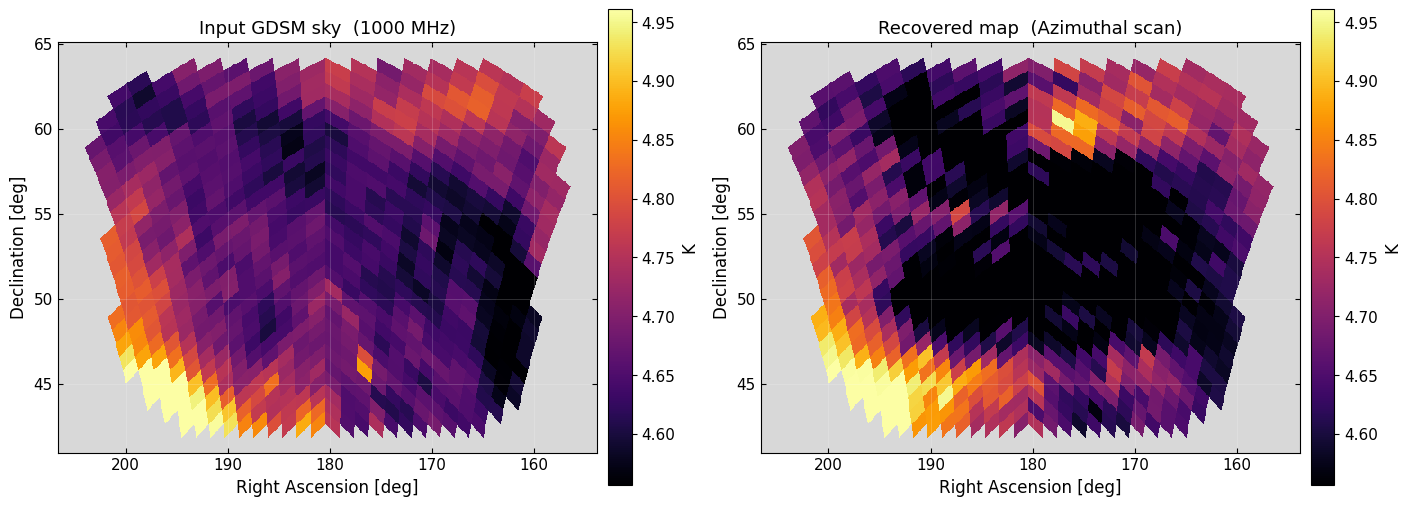

In [6]:
# Quick-look comparison. Save path is suffixed `_notebook` so it does
# not collide with the proposal/focus figures written by the scripts
# (`figures/compare_focus_meerklass_baseline__autonoise_ns64_hp.png`).
fig = plot_map_compare(
    sky_est=sky_map_est,
    sky_truth=sky_truth,
    nside=sky_Nside_map,
    pixel_indices=pixel_indices,
    freq_mhz=freq_list[0],
    strategy_name="Azimuthal scan",
    savepath="figures/map_meerklass_notebook.png",
)
plt.show()